In [1]:
%pip install statsmodels


Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)


In [3]:
import matplotlib.pyplot as plt

from src.data_loader import load_traffic_data
from src.data_overview import convert_timestamp
from src.preprocessing import (
    set_time_index,
    handle_missing_values,
    resample_daily,
    train_test_split
)
from src.forecasting import (
    train_sarima_model,
    make_forecast,
    evaluate_forecast
)


In [4]:
df = load_traffic_data()
df = convert_timestamp(df)
df = set_time_index(df)
df = handle_missing_values(df)

daily_df = resample_daily(df)
train_df, test_df = train_test_split(daily_df, test_days=14)

print("Train size:", len(train_df))
print("Test size:", len(test_df))


Train size: 105
Test size: 14


In [5]:
print("Daily Data Info:")
print(daily_df.describe())
print("\nRows:", len(daily_df))

Daily Data Info:
        TrafficCount
count     119.000000
mean   201643.361345
std    136603.470725
min         0.000000
25%     39997.500000
50%    246147.000000
75%    309621.500000
max    466050.000000

Rows: 119


In [6]:
model = train_sarima_model(train_df)
print("Model trained successfully!")


Model trained successfully!


In [7]:
metrics = evaluate_forecast(model, test_df)
metrics


{'MAE': 43899.876, 'RMSE': np.float64(52656.058), 'SMAPE': np.float64(95.783)}

In [8]:
# Naive baseline (previous day prediction)
naive_pred = test_df.shift(1)

from sklearn.metrics import mean_absolute_error

baseline_mae = mean_absolute_error(
    test_df[1:],  # skip first because shift creates NaN
    naive_pred[1:]
)

print("Baseline MAE:", baseline_mae)

Baseline MAE: 80762.46153846153


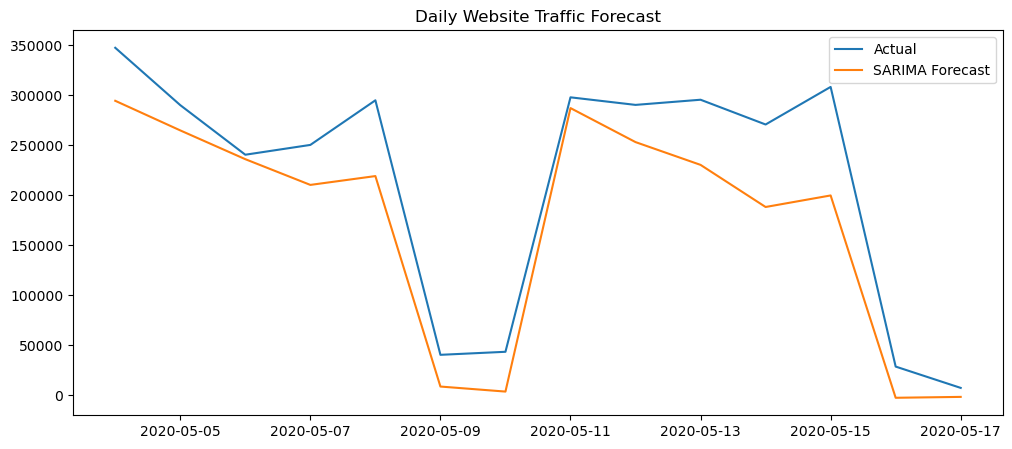

In [9]:
plt.figure(figsize=(12,5))
plt.plot(test_df.index, test_df, label="Actual")
plt.plot(test_df.index,
         model.forecast(len(test_df)),
         label="SARIMA Forecast")
plt.legend()
plt.title("Daily Website Traffic Forecast")
plt.show()

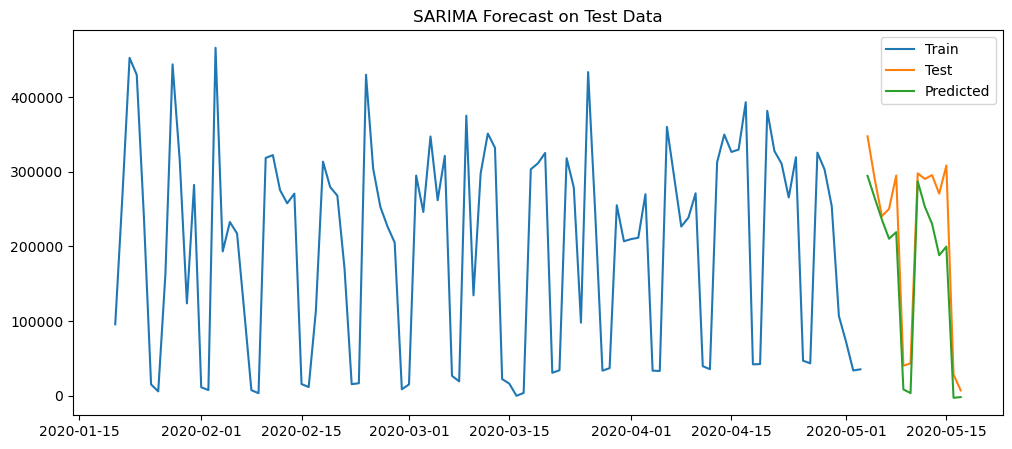

In [10]:
predictions = model.forecast(steps=len(test_df))

plt.figure(figsize=(12,5))
plt.plot(train_df.index, train_df, label="Train")
plt.plot(test_df.index, test_df, label="Test")
plt.plot(test_df.index, predictions, label="Predicted")
plt.legend()
plt.title("SARIMA Forecast on Test Data")
plt.show()


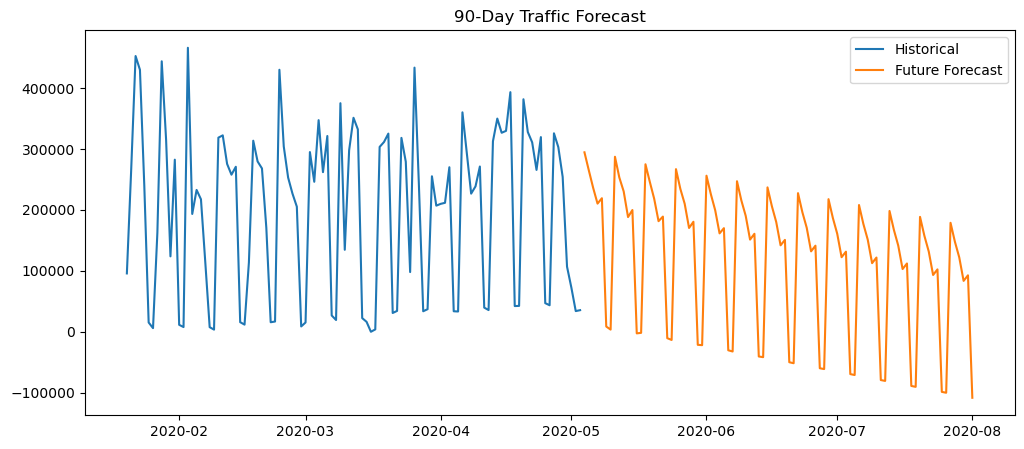

In [11]:
future_forecast = make_forecast(model, steps=90)

plt.figure(figsize=(12,5))
plt.plot(train_df.index, train_df, label="Historical")
plt.plot(future_forecast.index, future_forecast, label="Future Forecast")
plt.legend()
plt.title("90-Day Traffic Forecast")
plt.show()
